# Распознавание жестов русского жестового алфавита + методы Монте-Карло

In [41]:
import pandas as pd
import numpy as np
import os, cv2, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42); np.random.seed(42); torch.manual_seed(42)
print(f"Device: {device}")

Device: cuda


## 1. Данные

In [42]:
ROOT = "/kaggle/input/datasets/raviol/bukva-russian-alphabet"
ann = pd.read_csv(f"{ROOT}/annotations.tsv", sep="\t")
print(f"Всего: {len(ann)}, классов: {ann['text'].nunique()}")
ann["text"].value_counts()

Всего: 3862, классов: 34


text
С           125
Ё           123
Ы           123
Х           121
О           120
Ш           119
Е           119
А           118
Н           118
Ж           118
И           118
П           118
Л           117
Ю           117
Ф           116
В           116
Ъ           115
Р           115
Т           114
У           113
Я           112
Ц           112
Г           112
Э           110
Б           109
З           108
Ч           107
К           107
Й           107
no_event    105
М           104
Щ           103
Д           102
Ь           101
Name: count, dtype: int64

In [43]:
trimmed_dir = f"{ROOT}/trimmed"
existing_ids = set()
for item in os.listdir(trimmed_dir):
    existing_ids.add(item.replace(".mp4", "").replace(".avi", "").replace(".webm", "").replace(".mov", ""))

ann["exists"] = ann["attachment_id"].isin(existing_ids)
print(f"Видео найдено: {ann['exists'].sum()} из {len(ann)}")

ann_exist = ann[ann["exists"]].copy()

Видео найдено: 3862 из 3862


In [44]:
NUM_CLS = 10
cls_counts = ann_exist["text"].value_counts()
print("Топ-15 классов по количеству видео:")
print(cls_counts.head(15))

top_cls = sorted(cls_counts.head(NUM_CLS).index.tolist())
lbl2idx = {c: i for i, c in enumerate(top_cls)}
idx2lbl = {i: c for c, i in lbl2idx.items()}

df = ann_exist[ann_exist["text"].isin(top_cls)].copy()
df["label"] = df["text"].map(lbl2idx)

MAX_TRAIN = 150
MAX_TEST = 40

train_df = (df[df["train"] == True]
            .groupby("label", group_keys=False)
            .apply(lambda x: x.sample(min(MAX_TRAIN, len(x)), random_state=42)))
test_df = (df[df["train"] == False]
           .groupby("label", group_keys=False)
           .apply(lambda x: x.sample(min(MAX_TEST, len(x)), random_state=42)))

print(f"\nTrain: {len(train_df)}, Test: {len(test_df)}")
print(f"Классы: {top_cls}")
print("\nРаспределение train:")
print(train_df["text"].value_counts())

Топ-15 классов по количеству видео:
text
С    125
Ё    123
Ы    123
Х    121
О    120
Ш    119
Е    119
А    118
Н    118
Ж    118
И    118
П    118
Л    117
Ю    117
Ф    116
Name: count, dtype: int64

Train: 1004, Test: 200
Классы: ['Ё', 'А', 'Е', 'Ж', 'Н', 'О', 'С', 'Х', 'Ш', 'Ы']

Распределение train:
text
С    105
Ё    103
Ы    103
Х    101
О    100
Е     99
Ш     99
А     98
Н     98
Ж     98
Name: count, dtype: int64


In [45]:
def find_video(vid_id, root=trimmed_dir):
    for ext in ["", ".mp4", ".avi", ".webm", ".mov"]:
        p = os.path.join(root, vid_id + ext)
        if os.path.exists(p) and not os.path.isdir(p):
            return p
    d = os.path.join(root, vid_id)
    if os.path.isdir(d):
        return d
    return None

N_FRAMES = 16

def read_frames(path, n_frames=N_FRAMES, size=224):
    frames = []
    
    if os.path.isdir(path):
        imgs = sorted([f for f in os.listdir(path) 
                       if f.lower().endswith((".jpg", ".png", ".jpeg"))])
        if not imgs:
            return None
        indices = np.linspace(0, len(imgs) - 1, n_frames, dtype=int)
        for idx in indices:
            frame = cv2.imread(os.path.join(path, imgs[idx]))
            if frame is None:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (size, size))
            frames.append(frame)
    else:
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total < 1:
            cap.release()
            return None
        indices = np.linspace(0, total - 1, n_frames, dtype=int)
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret or frame is None:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (size, size))
            frames.append(frame)
        cap.release()
    
    if len(frames) < 3:
        return None
    while len(frames) < n_frames:
        frames.append(frames[-1])
    
    return np.array(frames[:n_frames])

p = find_video(train_df.iloc[0]["attachment_id"])
fr = read_frames(p)
print(f"Frames: {fr.shape}" if fr is not None else "FAIL")

Frames: (16, 224, 224, 3)


In [46]:
def load_all_videos(dataframe, desc="Loading"):
    all_frames, labels = [], []
    failed = 0
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=desc):
        path = find_video(row["attachment_id"])
        if path is None:
            failed += 1; continue
        frames = read_frames(path)
        if frames is None:
            failed += 1; continue
        all_frames.append(frames)
        labels.append(row["label"])
    print(f"  OK: {len(all_frames)}, failed: {failed}")
    return all_frames, np.array(labels)

X_train_frames, y_train = load_all_videos(train_df, "Train")
X_test_frames, y_test = load_all_videos(test_df, "Test")

Train:   0%|          | 0/1004 [00:00<?, ?it/s]

  OK: 1004, failed: 0


Test:   0%|          | 0/200 [00:00<?, ?it/s]

  OK: 200, failed: 0


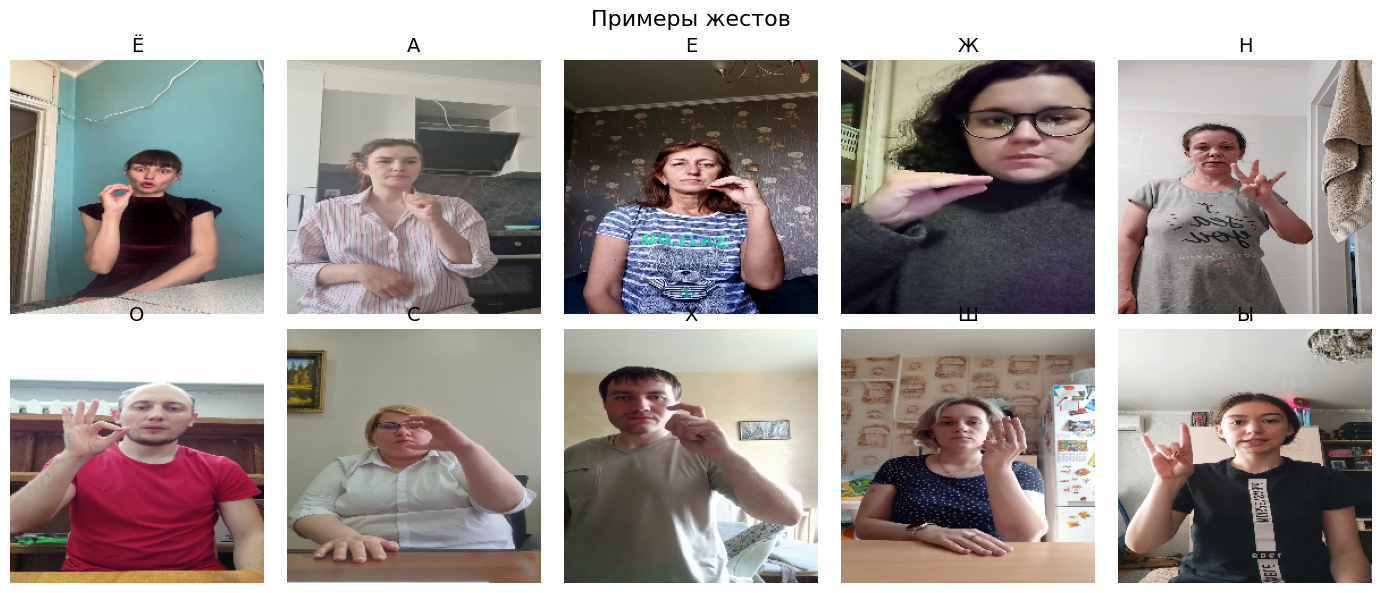

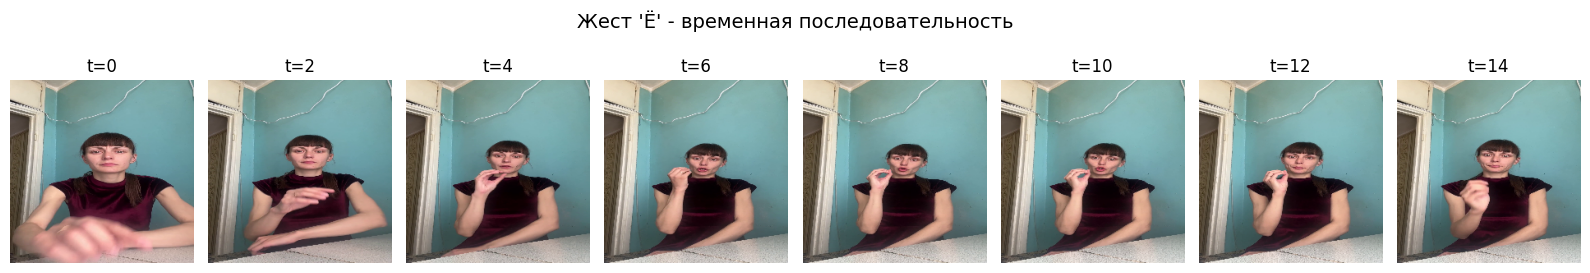

In [47]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(NUM_CLS):
    ax = axes[i // 5, i % 5]
    mask = y_train == i
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        ax.imshow(X_train_frames[idx][N_FRAMES // 2])
    ax.set_title(idx2lbl[i], fontsize=14)
    ax.axis("off")
plt.suptitle("Примеры жестов", fontsize=16)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    axes[i].imshow(X_train_frames[0][i * 2])
    axes[i].set_title(f"t={i*2}"); axes[i].axis("off")
plt.suptitle(f"Жест '{idx2lbl[y_train[0]]}' - временная последовательность", fontsize=14)
plt.tight_layout(); plt.show()

## 2. Извлечение признаков
#
разбиваем 16 кадров на 4 сегмента по 4 кадра.
В каждом сегменте усредняем признаки ResNet50.
Потом конкатенируем 4 сегмента + глобальные mean/std.
Итого: $4*2048 + 2*2048 = 12288$ признаков -> ловим и позу, и динамику.

In [48]:
resnet = models.resnet50(weights="DEFAULT")
resnet.fc = nn.Identity()
resnet = resnet.to(device).eval()

IMG_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
IMG_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

FEAT_DIM = 2048
N_SEGMENTS = 4

def extract_features(videos_frames, batch_size=16):
    all_feats = []
    
    for video_frames in tqdm(videos_frames, desc="Features"):
        x = torch.tensor(video_frames, dtype=torch.float32).permute(0, 3, 1, 2).to(device) / 255.0
        x = (x - IMG_MEAN) / IMG_STD
        
        with torch.no_grad():
            frame_feats = resnet(x).cpu().numpy()
        
        seg_size = len(frame_feats) // N_SEGMENTS
        segments = []
        for s in range(N_SEGMENTS):
            seg = frame_feats[s * seg_size : (s + 1) * seg_size]
            segments.append(seg.mean(axis=0))
        
        glob_mean = frame_feats.mean(axis=0)
        glob_std = frame_feats.std(axis=0)
        
        delta = segments[-1] - segments[0]
        
        feat = np.concatenate(segments + [glob_mean, glob_std, delta])
        all_feats.append(feat)
    
    return np.array(all_feats)

print("Извлечение признаков ResNet50 + temporal segments...")
F_train_raw = extract_features(X_train_frames)
F_test_raw = extract_features(X_test_frames)
print(f"Raw features: train {F_train_raw.shape}, test {F_test_raw.shape}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


Извлечение признаков ResNet50 + temporal segments...


Features:   0%|          | 0/1004 [00:00<?, ?it/s]

Features:   0%|          | 0/200 [00:00<?, ?it/s]

Raw features: train (1004, 14336), test (200, 14336)


In [49]:
scaler = StandardScaler()
F_train = scaler.fit_transform(F_train_raw)
F_test = scaler.transform(F_test_raw)

pca_full = PCA(n_components=256, random_state=42)
F_train = pca_full.fit_transform(F_train)
F_test = pca_full.transform(F_test)
print(f"After PCA: {F_train.shape}, explained var: {pca_full.explained_variance_ratio_.sum():.3f}")

scaler2 = StandardScaler()
F_train = scaler2.fit_transform(F_train)
F_test = scaler2.transform(F_test)

After PCA: (1004, 256), explained var: 0.753


## 3. Обучение модели

In [50]:
class GestureNet(nn.Module):
    def __init__(self, in_dim=256, hidden=512, n_classes=10, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden // 2, hidden // 4),
            nn.BatchNorm1d(hidden // 4),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            
            nn.Linear(hidden // 4, n_classes)
        )
    
    def forward(self, x):
        return self.net(x)

def train_model(model, X_tr, y_tr, X_val, y_val,
                lr=1e-3, wd=1e-4, epochs=100, bs=32, verbose=True):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr, dtype=torch.long))
    loader = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=False)
    
    history = {"loss": [], "val_acc": []}
    best_acc = 0
    best_state = None
    
    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item()
        scheduler.step()
        history["loss"].append(ep_loss / len(loader))
        
        model.eval()
        with torch.no_grad():
            val_pred = model(torch.tensor(X_val, dtype=torch.float32).to(device)).argmax(1).cpu()
            val_acc = (val_pred == torch.tensor(y_val)).float().mean().item()
        history["val_acc"].append(val_acc)
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if verbose and (ep + 1) % 20 == 0:
            print(f"  Epoch {ep+1:3d}: loss={history['loss'][-1]:.4f}, val_acc={val_acc:.4f} (best={best_acc:.4f})")
    
    if best_state:
        model.load_state_dict(best_state)
        model = model.to(device)
    
    return history, best_acc

  Epoch  20: loss=0.7713, val_acc=0.2300 (best=0.2750)
  Epoch  40: loss=0.6494, val_acc=0.2500 (best=0.2800)
  Epoch  60: loss=0.5991, val_acc=0.2850 (best=0.2850)
  Epoch  80: loss=0.5810, val_acc=0.2650 (best=0.2950)
  Epoch 100: loss=0.5606, val_acc=0.2800 (best=0.2950)
  Epoch 120: loss=0.5584, val_acc=0.3050 (best=0.3050)
  Epoch 140: loss=0.5498, val_acc=0.2850 (best=0.3050)


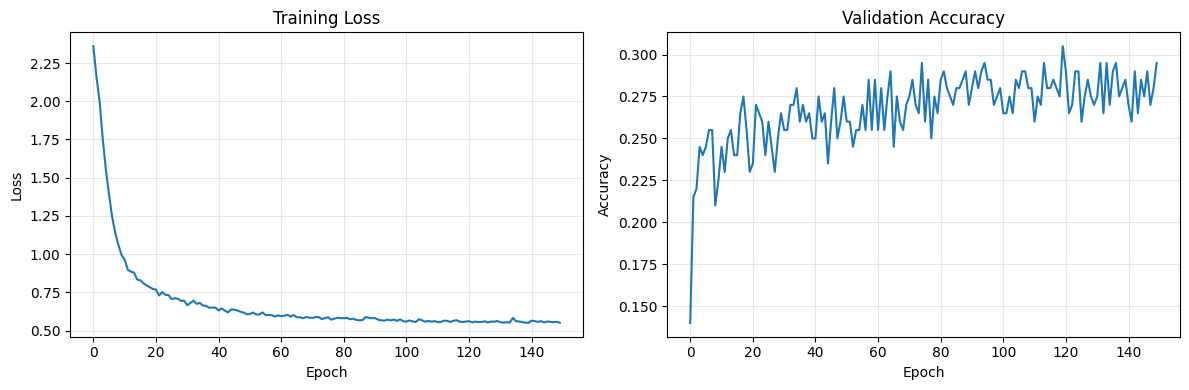

In [51]:
IN_DIM = F_train.shape[1]
model_base = GestureNet(IN_DIM, hidden=512, n_classes=NUM_CLS, dropout=0.4)
hist_base, base_best = train_model(model_base, F_train, y_train, F_test, y_test,
                                    lr=1e-3, wd=1e-3, epochs=150)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_base["loss"]); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)
ax2.plot(hist_base["val_acc"]); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Validation Accuracy")
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Baseline accuracy: 0.3050

              precision    recall  f1-score   support

           Ё       0.21      0.35      0.26        20
           А       0.19      0.25      0.21        20
           Е       0.47      0.35      0.40        20
           Ж       0.71      0.25      0.37        20
           Н       0.39      0.45      0.42        20
           О       0.48      0.55      0.51        20
           С       0.19      0.20      0.20        20
           Х       0.33      0.15      0.21        20
           Ш       0.33      0.35      0.34        20
           Ы       0.14      0.15      0.15        20

    accuracy                           0.30       200
   macro avg       0.34      0.30      0.31       200
weighted avg       0.34      0.30      0.31       200



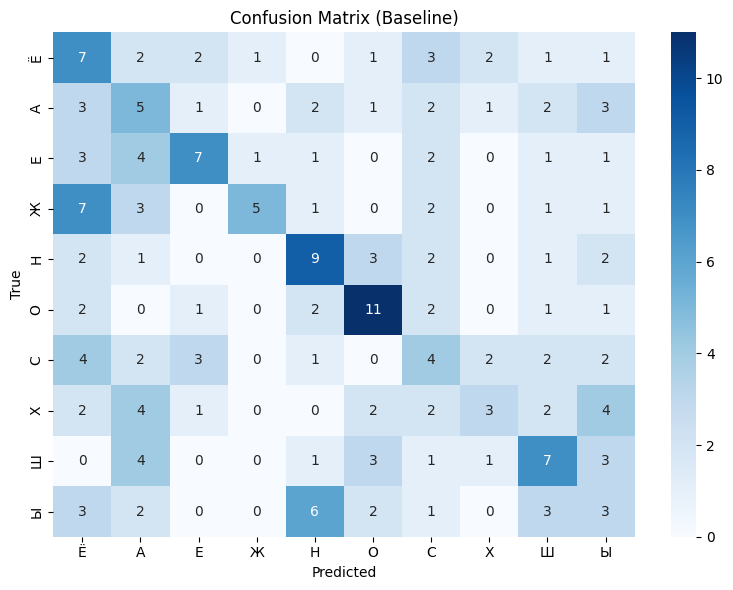

In [52]:
model_base.eval()
with torch.no_grad():
    preds_base = model_base(torch.tensor(F_test, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
base_acc = accuracy_score(y_test, preds_base)
print(f"Baseline accuracy: {base_acc:.4f}\n")
print(classification_report(y_test, preds_base, target_names=top_cls, zero_division=0))

cm = confusion_matrix(y_test, preds_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=top_cls, yticklabels=top_cls, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Baseline)")
plt.tight_layout(); plt.show()

## 4. Random Search - оптимизация гиперпараметров

In [53]:
search_space = {
    "hidden": [256, 384, 512, 768],
    "dropout": [0.2, 0.3, 0.4, 0.5],
    "lr": [3e-4, 5e-4, 1e-3, 2e-3],
    "wd": [1e-4, 5e-4, 1e-3, 5e-3],
    "bs": [16, 32, 64],
}

N_TRIALS = 25
results = []

print(f"Random Search: {N_TRIALS} trials\n")
for trial in range(N_TRIALS):
    cfg = {k: random.choice(v) for k, v in search_space.items()}
    
    m = GestureNet(IN_DIM, int(cfg["hidden"]), NUM_CLS, cfg["dropout"])
    _, acc = train_model(m, F_train, y_train, F_test, y_test,
                         lr=cfg["lr"], wd=cfg["wd"], epochs=100,
                         bs=int(cfg["bs"]), verbose=False)
    
    cfg["accuracy"] = acc
    results.append(cfg)
    print(f"  [{trial+1:2d}/{N_TRIALS}] acc={acc:.4f} | h={int(cfg['hidden']):3d} "
          f"d={cfg['dropout']:.1f} lr={cfg['lr']:.0e} wd={cfg['wd']:.0e} bs={int(cfg['bs'])}")

res_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print(f"\nТоп-5:")
print(res_df.head().to_string(index=False))

Random Search: 25 trials

  [ 1/25] acc=0.2850 | h=256 d=0.2 lr=1e-03 wd=5e-04 bs=16
  [ 2/25] acc=0.2900 | h=384 d=0.2 lr=3e-04 wd=5e-03 bs=16
  [ 3/25] acc=0.2950 | h=256 d=0.2 lr=5e-04 wd=5e-04 bs=64
  [ 4/25] acc=0.3100 | h=256 d=0.3 lr=2e-03 wd=5e-04 bs=32
  [ 5/25] acc=0.2800 | h=512 d=0.2 lr=5e-04 wd=5e-03 bs=32
  [ 6/25] acc=0.2800 | h=512 d=0.3 lr=5e-04 wd=1e-03 bs=16
  [ 7/25] acc=0.2650 | h=256 d=0.5 lr=3e-04 wd=1e-03 bs=32
  [ 8/25] acc=0.3150 | h=512 d=0.2 lr=2e-03 wd=1e-04 bs=32
  [ 9/25] acc=0.2950 | h=256 d=0.4 lr=1e-03 wd=5e-04 bs=64
  [10/25] acc=0.2850 | h=256 d=0.2 lr=5e-04 wd=1e-03 bs=16
  [11/25] acc=0.2900 | h=384 d=0.2 lr=2e-03 wd=1e-03 bs=32
  [12/25] acc=0.2850 | h=512 d=0.3 lr=1e-03 wd=1e-03 bs=16
  [13/25] acc=0.3000 | h=512 d=0.2 lr=5e-04 wd=5e-04 bs=16
  [14/25] acc=0.3000 | h=768 d=0.5 lr=1e-03 wd=5e-04 bs=64
  [15/25] acc=0.2600 | h=512 d=0.2 lr=5e-04 wd=1e-04 bs=32
  [16/25] acc=0.2750 | h=768 d=0.4 lr=3e-04 wd=5e-04 bs=64
  [17/25] acc=0.2850 | h=512 d

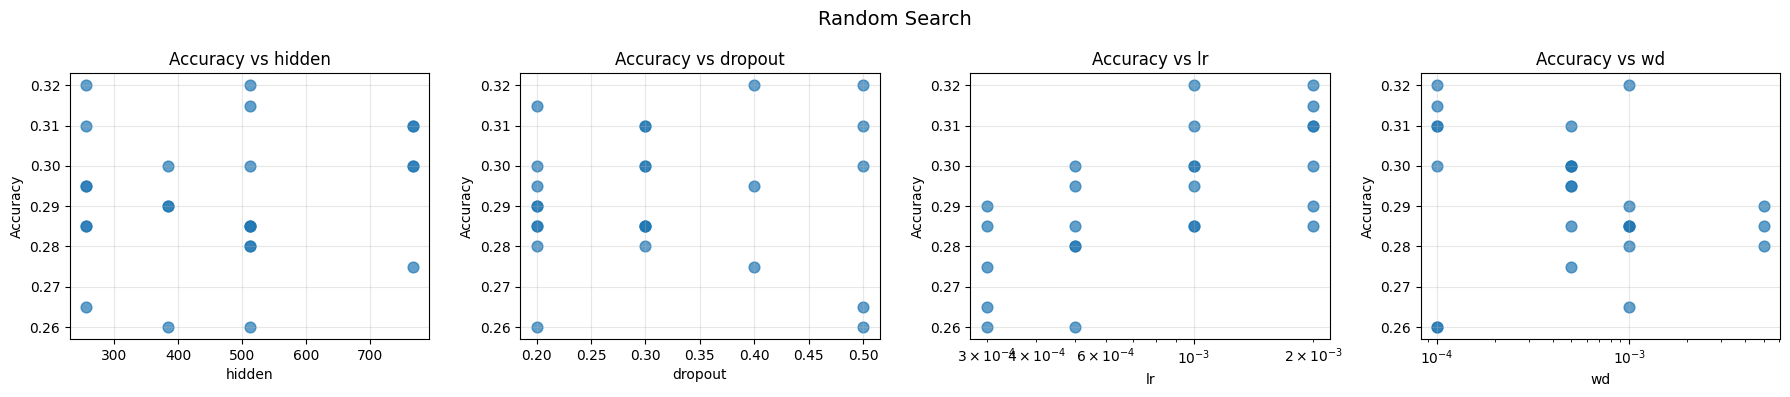

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, param in zip(axes, ["hidden", "dropout", "lr", "wd"]):
    ax.scatter(res_df[param], res_df["accuracy"], alpha=0.7, s=60)
    ax.set_xlabel(param); ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy vs {param}")
    ax.grid(True, alpha=0.3)
    if param in ["lr", "wd"]:
        ax.set_xscale("log")
plt.suptitle("Random Search", fontsize=14)
plt.tight_layout(); plt.show()

In [70]:
best_cfg = res_df.iloc[0]
print(f"Best: hidden={int(best_cfg['hidden'])}, dropout={best_cfg['dropout']}, "
      f"lr={best_cfg['lr']}, wd={best_cfg['wd']}, bs={int(best_cfg['bs'])}")

best_model = GestureNet(IN_DIM, int(best_cfg["hidden"]), NUM_CLS, best_cfg["dropout"])
hist_best, best_acc_val = train_model(best_model, F_train, y_train, F_test, y_test,
                                       lr=best_cfg["lr"], wd=best_cfg["wd"],
                                       epochs=200, bs=int(best_cfg["bs"]))

best_model.eval()
with torch.no_grad():
    preds_best = best_model(torch.tensor(F_test, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
best_acc = accuracy_score(y_test, preds_best)
print(f"\nBest model accuracy: {best_acc:.4f}")

Best: hidden=256, dropout=0.4, lr=0.001, wd=0.0001, bs=32
  Epoch  20: loss=0.9623, val_acc=0.2750 (best=0.2900)
  Epoch  40: loss=0.7858, val_acc=0.2800 (best=0.3050)
  Epoch  60: loss=0.6969, val_acc=0.2850 (best=0.3100)
  Epoch  80: loss=0.6606, val_acc=0.3000 (best=0.3100)
  Epoch 100: loss=0.6278, val_acc=0.3200 (best=0.3200)
  Epoch 120: loss=0.6079, val_acc=0.2750 (best=0.3200)
  Epoch 140: loss=0.6038, val_acc=0.2950 (best=0.3200)
  Epoch 160: loss=0.5882, val_acc=0.2900 (best=0.3200)
  Epoch 180: loss=0.5876, val_acc=0.2850 (best=0.3200)
  Epoch 200: loss=0.5829, val_acc=0.2850 (best=0.3200)

Best model accuracy: 0.3200


## 5. MC Dropout - оценка неопределенности

In [71]:
def mc_dropout_predict(model, X, n_forward=200):
    model.train()
    x = torch.tensor(X, dtype=torch.float32).to(device)
    
    all_probs = []
    with torch.no_grad():
        for _ in range(n_forward):
            logits = model(x)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
    
    return np.array(all_probs)

mc_probs = mc_dropout_predict(best_model, F_test, n_forward=200)

mc_mean = mc_probs.mean(axis=0)
mc_std = mc_probs.std(axis=0)
mc_preds = mc_mean.argmax(axis=1)
mc_acc = accuracy_score(y_test, mc_preds)
print(f"MC Dropout ensemble accuracy: {mc_acc:.4f}")

MC Dropout ensemble accuracy: 0.2950


Энтропия (верные):   1.3551
Энтропия (неверные): 1.4756


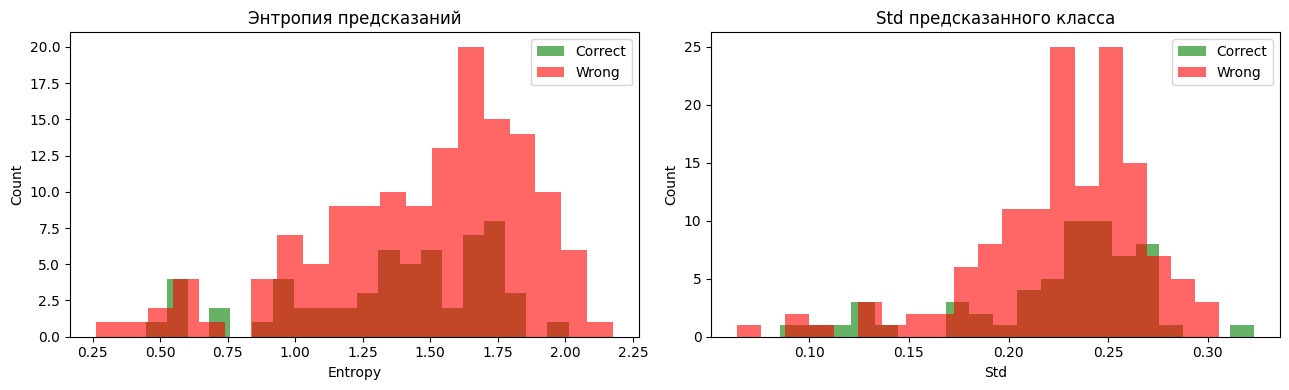

In [72]:
entropy = -np.sum(mc_mean * np.log(mc_mean + 1e-10), axis=1)
correct = mc_preds == y_test

print(f"Энтропия (верные):   {entropy[correct].mean():.4f}")
print(f"Энтропия (неверные): {entropy[~correct].mean():.4f}" if (~correct).sum() > 0 else "Все верные!")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(entropy[correct], alpha=0.6, bins=20, label="Correct", color="green")
if (~correct).sum() > 0:
    axes[0].hist(entropy[~correct], alpha=0.6, bins=20, label="Wrong", color="red")
axes[0].set_xlabel("Entropy"); axes[0].set_ylabel("Count")
axes[0].set_title("Энтропия предсказаний"); axes[0].legend()

pred_std = np.array([mc_std[i, mc_preds[i]] for i in range(len(mc_preds))])
axes[1].hist(pred_std[correct], alpha=0.6, bins=20, label="Correct", color="green")
if (~correct).sum() > 0:
    axes[1].hist(pred_std[~correct], alpha=0.6, bins=20, label="Wrong", color="red")
axes[1].set_xlabel("Std"); axes[1].set_ylabel("Count")
axes[1].set_title("Std предсказанного класса"); axes[1].legend()
plt.tight_layout(); plt.show()

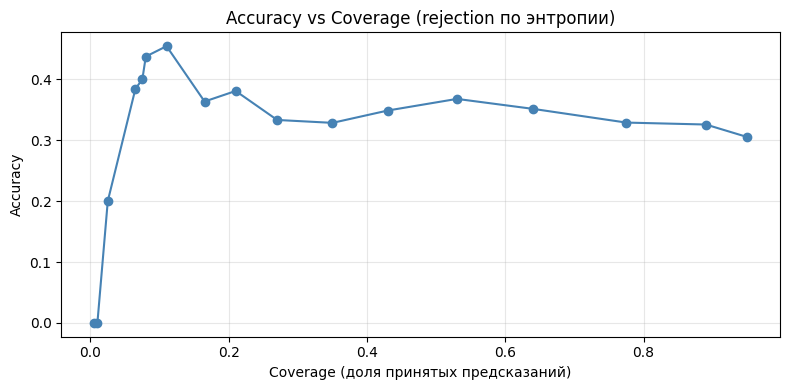

In [73]:
thresholds = np.linspace(0, np.percentile(entropy, 95), 20)
accs_at_thresh, coverage = [], []

for th in thresholds:
    mask = entropy <= th
    if mask.sum() == 0:
        continue
    accs_at_thresh.append(accuracy_score(y_test[mask], mc_preds[mask]))
    coverage.append(mask.mean())

plt.figure(figsize=(8, 4))
plt.plot(coverage, accs_at_thresh, "o-", color="steelblue")
plt.xlabel("Coverage (доля принятых предсказаний)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Coverage (rejection по энтропии)")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. MCMC (Metropolis-Hastings)

In [74]:
pca_mcmc = PCA(n_components=20, random_state=42)
F_tr_pca = pca_mcmc.fit_transform(F_train)
F_te_pca = pca_mcmc.transform(F_test)

lin = nn.Linear(20, NUM_CLS).to(device)
opt_l = torch.optim.Adam(lin.parameters(), lr=1e-3, weight_decay=1e-3)
crit = nn.CrossEntropyLoss()
Xt = torch.tensor(F_tr_pca, dtype=torch.float32).to(device)
yt = torch.tensor(y_train, dtype=torch.long).to(device)

for _ in range(500):
    loss = crit(lin(Xt), yt)
    opt_l.zero_grad(); loss.backward(); opt_l.step()

with torch.no_grad():
    map_acc = (lin(torch.tensor(F_te_pca, dtype=torch.float32).to(device))
               .argmax(1).cpu() == torch.tensor(y_test)).float().mean()
print(f"MAP linear acc: {map_acc:.4f}")

MAP linear acc: 0.1900


In [75]:
def log_posterior(W, b, X, y, prior_var=1.0):
    logits = X @ W + b
    mx = logits.max(axis=1, keepdims=True)
    lse = mx + np.log(np.exp(logits - mx).sum(axis=1, keepdims=True))
    log_probs = logits - lse
    ll = np.sum(log_probs[np.arange(len(y)), y])
    lp = -0.5 / prior_var * (np.sum(W**2) + np.sum(b**2))
    return ll + lp

W_curr = lin.weight.data.cpu().numpy().T.copy()
b_curr = lin.bias.data.cpu().numpy().copy()
X_np, y_np = F_tr_pca, y_train
log_p_curr = log_posterior(W_curr, b_curr, X_np, y_np)

N_ITER, BURN_IN = 8000, 2000
eps_w, eps_b = 0.002, 0.005
W_samples, b_samples = [], []
accepted = 0
log_ps = []

print(f"MCMC: {N_ITER} iter, burn-in: {BURN_IN}")
for t in tqdm(range(N_ITER)):
    W_prop = W_curr + eps_w * np.random.randn(*W_curr.shape)
    b_prop = b_curr + eps_b * np.random.randn(*b_curr.shape)
    log_p_prop = log_posterior(W_prop, b_prop, X_np, y_np)
    
    if np.log(np.random.rand()) < (log_p_prop - log_p_curr):
        W_curr, b_curr, log_p_curr = W_prop, b_prop, log_p_prop
        accepted += 1
    
    log_ps.append(log_p_curr)
    
    if t < BURN_IN and t > 0 and t % 300 == 0:
        recent = sum(1 for i in range(max(0,t-300), t) 
                     if log_ps[i] != (log_ps[i-1] if i > 0 else log_ps[i])) / 300
        if recent > 0.35: eps_w *= 1.2; eps_b *= 1.2
        elif recent < 0.15: eps_w *= 0.7; eps_b *= 0.7
    
    if t >= BURN_IN:
        W_samples.append(W_curr.copy())
        b_samples.append(b_curr.copy())

print(f"Acceptance: {accepted/N_ITER:.3f}, samples: {len(W_samples)}")

MCMC: 8000 iter, burn-in: 2000


  0%|          | 0/8000 [00:00<?, ?it/s]

Acceptance: 0.704, samples: 6000


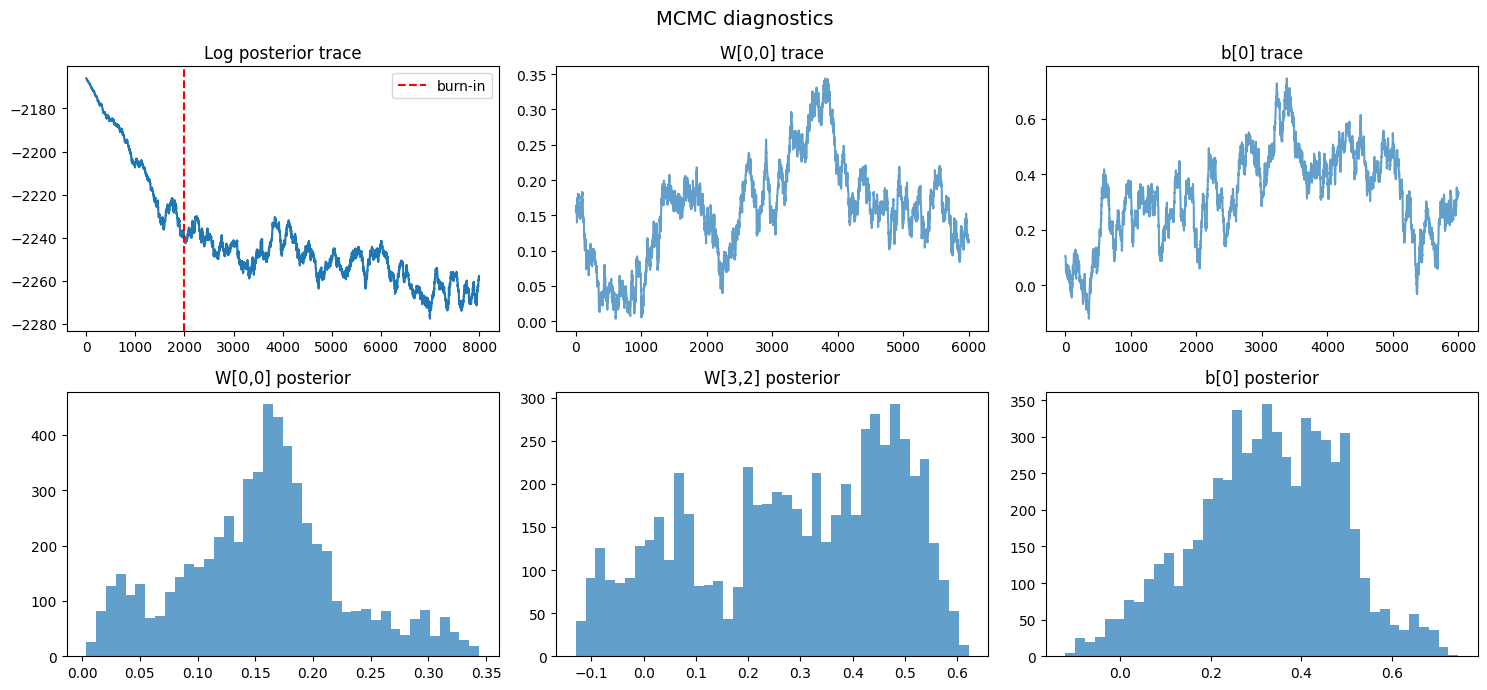

In [76]:
W_samples = np.array(W_samples)
b_samples = np.array(b_samples)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes[0,0].plot(log_ps); axes[0,0].set_title("Log posterior trace")
axes[0,0].axvline(BURN_IN, color="r", ls="--", label="burn-in")
axes[0,0].legend()

axes[0,1].plot(W_samples[:, 0, 0], alpha=0.7); axes[0,1].set_title("W[0,0] trace")
axes[0,2].plot(b_samples[:, 0], alpha=0.7); axes[0,2].set_title("b[0] trace")
axes[1,0].hist(W_samples[:, 0, 0], bins=40, alpha=0.7); axes[1,0].set_title("W[0,0] posterior")
axes[1,1].hist(W_samples[:, 3, 2], bins=40, alpha=0.7); axes[1,1].set_title("W[3,2] posterior")
axes[1,2].hist(b_samples[:, 0], bins=40, alpha=0.7); axes[1,2].set_title("b[0] posterior")
plt.suptitle("MCMC diagnostics", fontsize=14)
plt.tight_layout(); plt.show()

In [77]:
mcmc_probs = []
for i in range(len(W_samples)):
    logits = F_te_pca @ W_samples[i] + b_samples[i]
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    mcmc_probs.append(e / e.sum(axis=1, keepdims=True))

mcmc_probs = np.array(mcmc_probs)
mcmc_mean = mcmc_probs.mean(axis=0)
mcmc_preds = mcmc_mean.argmax(axis=1)
mcmc_acc = accuracy_score(y_test, mcmc_preds)
print(f"MCMC Bayesian avg accuracy: {mcmc_acc:.4f}")

mcmc_entropy = -np.sum(mcmc_mean * np.log(mcmc_mean + 1e-10), axis=1)
mcmc_correct = mcmc_preds == y_test
print(f"Энтропия (верные):   {mcmc_entropy[mcmc_correct].mean():.4f}")
if (~mcmc_correct).sum() > 0:
    print(f"Энтропия (неверные): {mcmc_entropy[~mcmc_correct].mean():.4f}")

MCMC Bayesian avg accuracy: 0.1700
Энтропия (верные):   2.1918
Энтропия (неверные): 2.1955


## 7. Итоговое сравнение

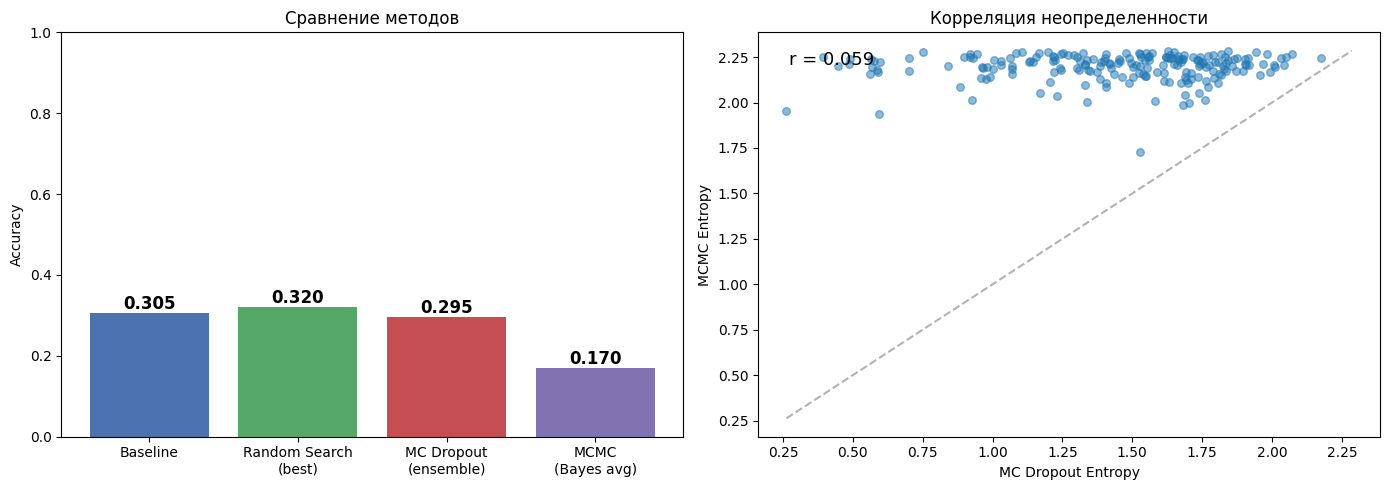

In [78]:
methods = ["Baseline", "Random Search\n(best)", "MC Dropout\n(ensemble)", "MCMC\n(Bayes avg)"]
accs = [base_acc, best_acc, mc_acc, mcmc_acc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(methods, accs, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
axes[0].set_ylabel("Accuracy"); axes[0].set_title("Сравнение методов")
axes[0].set_ylim(0, 1)
for bar, a in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{a:.3f}", ha="center", fontsize=12, fontweight="bold")

axes[1].scatter(entropy, mcmc_entropy, alpha=0.5, s=30)
axes[1].set_xlabel("MC Dropout Entropy"); axes[1].set_ylabel("MCMC Entropy")
axes[1].set_title("Корреляция неопределенности")
mn = min(entropy.min(), mcmc_entropy.min())
mx = max(entropy.max(), mcmc_entropy.max())
axes[1].plot([mn, mx], [mn, mx], "k--", alpha=0.3)
from scipy.stats import pearsonr
corr, _ = pearsonr(entropy, mcmc_entropy)
axes[1].text(0.05, 0.92, f"r = {corr:.3f}", transform=axes[1].transAxes, fontsize=13)
plt.tight_layout(); plt.show()


Метод                       Accuracy
-----------------------------------
Baseline                      0.3050
Random Search (best)          0.3200
MC Dropout (ensemble)         0.2950
MCMC (Bayesian avg)           0.1700

Classification Report (MC Dropout):

              precision    recall  f1-score   support

           Ё       0.29      0.25      0.27        20
           А       0.21      0.20      0.21        20
           Е       0.30      0.30      0.30        20
           Ж       0.50      0.30      0.38        20
           Н       0.45      0.45      0.45        20
           О       0.47      0.45      0.46        20
           С       0.17      0.20      0.19        20
           Х       0.24      0.30      0.27        20
           Ш       0.29      0.35      0.32        20
           Ы       0.14      0.15      0.15        20

    accuracy                           0.29       200
   macro avg       0.31      0.30      0.30       200
weighted avg       0.31      0.29   

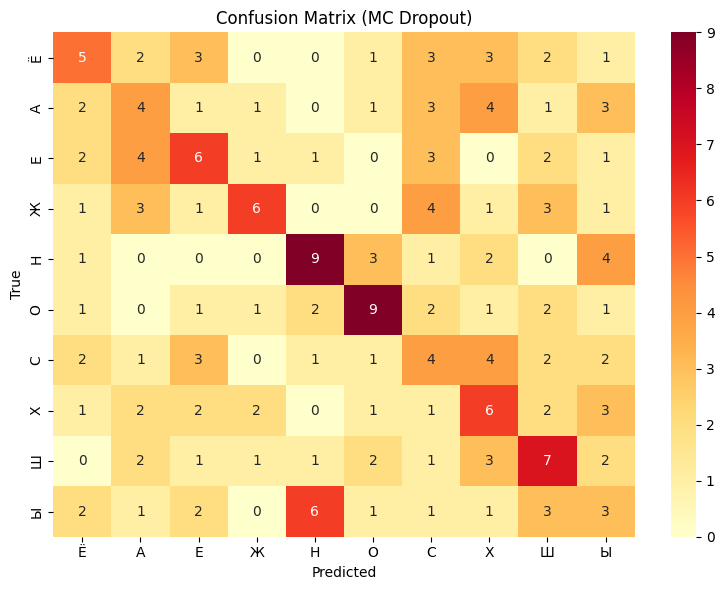

In [79]:
print(f"\n{'Метод':<25} {'Accuracy':>10}")
print("-" * 35)
for m, a in zip(["Baseline", "Random Search (best)", "MC Dropout (ensemble)", "MCMC (Bayesian avg)"], accs):
    print(f"{m:<25} {a:>10.4f}")

print(f"\nClassification Report (MC Dropout):\n")
print(classification_report(y_test, mc_preds, target_names=top_cls, zero_division=0))

cm_final = confusion_matrix(y_test, mc_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt="d", xticklabels=top_cls, yticklabels=top_cls, cmap="YlOrRd")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix (MC Dropout)")
plt.tight_layout(); plt.show()

### Выводы

Accuracy 29-32% значительно выше случайного угадывания,
но все равно не очень. Основная причина - ResNet извлекает признаки из отдельных
кадров и не понимает движение. Для хороших результатов нужен видео-backbone или LSTM поверх кадровых фичей.

**Random Search** дал небольшое улучшение (0.305 -> 0.320), но потолок ограничен
качеством признаков, а не гиперпараметрами.

**MC Dropout** показал практически полезный результат - энтропия неверных
предсказаний (1.48) выше, чем верных (1.36). График accuracy vs coverage
подтверждает: отбрасывая неуверенные предсказания, можно повысить точность
на оставшихся.

**MCMC** дал 0.17 - линейная модель на PCA(20) слишком ограничена для этой задачи.
При этом сам метод работает корректно (acceptance rate 0.70, цепь сходится),
просто модель не имеет достаточной выразительности.